In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, pearsonr
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
df = pd.read_excel("PSRI_RAG_DATA.xlsx")
df.head()

,Age,Gender,Landholding Size,Farming Experience,Area/Place,How do you sell your agricultural products?,Which marketing method do you use most frequently?,What type of agricultural products do you grow and sell?,What problems do you face in marketing your agricultural products?,Do you feel you get a fair price for your products?,...,Are you aware of direct marketing methods for agricultural products?,Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?,Which digital platform do you use most frequently?,Do digital platforms help in promoting agricultural products?,Would you prefer using digital platforms for marketing agricultural products?,Have digital payment methods improved your selling experience?,Do you think direct marketing can increase farmer income?,Are customers interested in purchasing products directly from farmers?,What initiatives should the Government take to improve the marketing of agricultural products?,Would you be interested in attending training programs on agricultural marketing and digital marketing?
0,30–45,Male,2–5 acres,More than 5 years,Tumkur Rural,Through middlemen,Middlemen,Grains,Middlemen control;Low price;Transport issues,No,...,Yes,Yes,WhatsApp,Yes,Yes,Yes,Yes,Yes,Reduce middlemen;Better transport facilities;G...,Yes
1,46–60,Male,More than 5 acres,More than 5 years,Gubbi,APMC market,Both,Vegetables,Low price;Delayed payments;Storage problems,No,...,Yes,Yes,UPI/PhonePe/GPay,Yes,Yes,Yes,Yes,Yes,Better storage facilities;Awareness programs,Yes
2,20–25,Female,Less than 2 acres,2–5 years,Tiptur,Direct to consumers,Direct selling,Flowers,Transport issues;Lack of awareness,Yes,...,Yes,Yes,Instagram,Yes,Yes,Yes,Yes,Yes,Awareness programs;Digital payment systems,Yes
3,30–45,Male,2–5 acres,More than 5 years,Kunigal,Through middlemen,Middlemen,Grains,Middlemen control;Low price;Delayed payments,No,...,No,No,Others,No,Yes,No,Yes,No,Reduce middlemen;Government support,Yes
4,46–60,Female,Less than 2 acres,More than 5 years,Turuvekere,Retail shops,Both,Vegetables,Low price;Transport issues,No,...,Yes,Yes,WhatsApp,Yes,Yes,Yes,Yes,Yes,Better transport facilities;Awareness programs,Yes


In [3]:
df.columns.tolist()

['Age',
 'Gender',
 'Landholding Size',
 'Farming Experience',
 'Area/Place',
 'How do you sell your agricultural products?',
 'Which marketing method do you use most frequently?',
 'What type of agricultural products do you grow and sell?',
 'What problems do you face in marketing your agricultural products?',
 'Do you feel you get a fair price for your products?',
 'Are transportation facilities adequate for marketing your products?',
 'Do you receive proper information about market prices?',
 'Are storage facilities adequate for preserving agricultural products?',
 'Do middlemen influence the pricing of your products?',
 'What opportunities do you see in marketing your agricultural products?',
 'Are you aware of direct marketing methods for agricultural products?',
 'Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?',
 'Which digital platform do you use most frequently?',
 'Do digital platforms help in promoting agricultural products?',
 'Would you prefer usi

In [4]:
df.shape

(115, 25)

In [5]:
df.head()

,Age,Gender,Landholding Size,Farming Experience,Area/Place,How do you sell your agricultural products?,Which marketing method do you use most frequently?,What type of agricultural products do you grow and sell?,What problems do you face in marketing your agricultural products?,Do you feel you get a fair price for your products?,...,Are you aware of direct marketing methods for agricultural products?,Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?,Which digital platform do you use most frequently?,Do digital platforms help in promoting agricultural products?,Would you prefer using digital platforms for marketing agricultural products?,Have digital payment methods improved your selling experience?,Do you think direct marketing can increase farmer income?,Are customers interested in purchasing products directly from farmers?,What initiatives should the Government take to improve the marketing of agricultural products?,Would you be interested in attending training programs on agricultural marketing and digital marketing?
0,30–45,Male,2–5 acres,More than 5 years,Tumkur Rural,Through middlemen,Middlemen,Grains,Middlemen control;Low price;Transport issues,No,...,Yes,Yes,WhatsApp,Yes,Yes,Yes,Yes,Yes,Reduce middlemen;Better transport facilities;G...,Yes
1,46–60,Male,More than 5 acres,More than 5 years,Gubbi,APMC market,Both,Vegetables,Low price;Delayed payments;Storage problems,No,...,Yes,Yes,UPI/PhonePe/GPay,Yes,Yes,Yes,Yes,Yes,Better storage facilities;Awareness programs,Yes
2,20–25,Female,Less than 2 acres,2–5 years,Tiptur,Direct to consumers,Direct selling,Flowers,Transport issues;Lack of awareness,Yes,...,Yes,Yes,Instagram,Yes,Yes,Yes,Yes,Yes,Awareness programs;Digital payment systems,Yes
3,30–45,Male,2–5 acres,More than 5 years,Kunigal,Through middlemen,Middlemen,Grains,Middlemen control;Low price;Delayed payments,No,...,No,No,Others,No,Yes,No,Yes,No,Reduce middlemen;Government support,Yes
4,46–60,Female,Less than 2 acres,More than 5 years,Turuvekere,Retail shops,Both,Vegetables,Low price;Transport issues,No,...,Yes,Yes,WhatsApp,Yes,Yes,Yes,Yes,Yes,Better transport facilities;Awareness programs,Yes


In [6]:
df.iloc[:, 9:25].nunique()

Do you feel you get a fair price for your products?                                                         2
Are transportation facilities adequate for marketing your products?                                         2
Do you receive proper information about market prices?                                                      2
Are storage facilities adequate for preserving agricultural products?                                       2
Do middlemen influence the pricing of your products?                                                        2
What opportunities do you see in marketing your agricultural products?                                     13
Are you aware of direct marketing methods for agricultural products?                                        2
Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?                                   2
Which digital platform do you use most frequently?                                                          5
Do digital

In [7]:
df['Do you feel you get a fair price for your products?'].unique()

array(['No', 'Yes'], dtype=object)

In [8]:
df['Are you aware of direct marketing methods for agricultural products?'].unique()

array(['Yes', 'No'], dtype=object)

**ENCODING**

In [9]:
yes_no_columns = [
    'Do you feel you get a fair price for your products?',
    'Are transportation facilities adequate for marketing your products?',
    'Do you receive proper information about market prices?',
    'Are storage facilities adequate for preserving agricultural products?',
    'Do middlemen influence the pricing of your products?',
    'Are you aware of direct marketing methods for agricultural products?',
    'Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?',
    'Do digital platforms help in promoting agricultural products?',
    'Would you prefer using digital platforms for marketing agricultural products?',
    'Have digital payment methods improved your selling experience?',
    'Are customers interested in purchasing products directly from farmers?',
    'Would you be interested in attending training programs on agricultural marketing and digital marketing?'
]

for col in yes_no_columns:
    df[col + '_code'] = df[col].map({'Yes':1, 'No':0})

print("Encoding Completed")

Encoding Completed


In [10]:
df.filter(regex='_code$').head()

,Do you feel you get a fair price for your products?_code,Are transportation facilities adequate for marketing your products?_code,Do you receive proper information about market prices?_code,Are storage facilities adequate for preserving agricultural products?_code,Do middlemen influence the pricing of your products?_code,Are you aware of direct marketing methods for agricultural products?_code,Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?_code,Do digital platforms help in promoting agricultural products?_code,Would you prefer using digital platforms for marketing agricultural products?_code,Have digital payment methods improved your selling experience?_code,Are customers interested in purchasing products directly from farmers?_code,Would you be interested in attending training programs on agricultural marketing and digital marketing?_code
0,0,0,0,0,1,1,1,1,1,1,1,1
1,0,0,1,0,1,1,1,1,1,1,1,1
2,1,1,1,0,0,1,1,1,1,1,1,1
3,0,0,0,0,1,0,0,0,1,0,0,1
4,0,0,1,0,1,1,1,1,1,1,1,1


**HYPOTHESIS TESTING - CHISQUARE**

In [11]:
# ==========================================================
# CHI-SQUARE TEST – HYPOTHESIS 1
# ==========================================================

from scipy.stats import chi2_contingency
import pandas as pd

print("="*80)
print("CHI-SQUARE TEST – HYPOTHESIS 1")
print("="*80)

print("\nNull Hypothesis (H₀):")
print("There is no significant association between awareness of direct marketing methods and the use of digital platforms for selling agricultural products.")

print("\nAlternative Hypothesis (H₁):")
print("There is a significant association between awareness of direct marketing methods and the use of digital platforms for selling agricultural products.")

print("\nLevel of Significance (α): 0.05")

# ----------------------------------------------------------
# Cross Tabulation
# ----------------------------------------------------------

cross_tab1 = pd.crosstab(
    df['Are you aware of direct marketing methods for agricultural products?'],
    df['Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?']
)

print("\n" + "="*80)
print("CROSS TABULATION")
print("="*80)
print(cross_tab1)

# ----------------------------------------------------------
# Chi-Square Test
# ----------------------------------------------------------

chi2, p, dof, expected = chi2_contingency(cross_tab1)

print("\n" + "="*80)
print("CHI-SQUARE TEST RESULTS")
print("="*80)

print(f"Chi-Square Statistic (χ²) : {chi2:.3f}")
print(f"Degrees of Freedom (df)   : {dof}")

if p < 0.001:
    print("P-value                  : < 0.001")
else:
    print(f"P-value                  : {p:.3f}")

print(f"Sample Size (N)          : {len(df)}")

# ----------------------------------------------------------
# Expected Frequencies
# ----------------------------------------------------------

expected_df = pd.DataFrame(
    expected,
    index=cross_tab1.index,
    columns=cross_tab1.columns
)

print("\n" + "="*80)
print("EXPECTED FREQUENCIES")
print("="*80)
print(expected_df.round(2))

# ----------------------------------------------------------
# Decision
# ----------------------------------------------------------

print("\n" + "="*80)
print("DECISION")
print("="*80)

if p < 0.05:
    print("Decision : Reject the Null Hypothesis (H₀)")
    print("Conclusion : There is a statistically significant association between awareness of direct marketing methods and the use of digital platforms for selling agricultural products.")
else:
    print("Decision : Fail to Reject the Null Hypothesis (H₀)")
    print("Conclusion : There is no statistically significant association between awareness of direct marketing methods and the use of digital platforms for selling agricultural products.")

CHI-SQUARE TEST – HYPOTHESIS 1

Null Hypothesis (H₀):
There is no significant association between awareness of direct marketing methods and the use of digital platforms for selling agricultural products.

Alternative Hypothesis (H₁):
There is a significant association between awareness of direct marketing methods and the use of digital platforms for selling agricultural products.

Level of Significance (α): 0.05

CROSS TABULATION
Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?  No  \
Are you aware of direct marketing methods for a...                              
No                                                                         31   
Yes                                                                         3   

Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?  Yes  
Are you aware of direct marketing methods for a...                              
No                                                                           0 

In [12]:
# ==========================================================
# CHI-SQUARE TEST – HYPOTHESIS 2
# ==========================================================

from scipy.stats import chi2_contingency
import pandas as pd

print("="*80)
print("CHI-SQUARE TEST – HYPOTHESIS 2")
print("="*80)

print("\nNull Hypothesis (H₀):")
print("There is no significant association between the use of digital platforms for selling and the perception that digital platforms help in promoting agricultural products.")

print("\nAlternative Hypothesis (H₁):")
print("There is a significant association between the use of digital platforms for selling and the perception that digital platforms help in promoting agricultural products.")

print("\nLevel of Significance (α): 0.05")

# ----------------------------------------------------------
# Cross Tabulation
# ----------------------------------------------------------

cross_tab2 = pd.crosstab(
    df['Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?'],
    df['Do digital platforms help in promoting agricultural products?']
)

print("\n" + "="*80)
print("CROSS TABULATION")
print("="*80)
print(cross_tab2)

# ----------------------------------------------------------
# Chi-Square Test
# ----------------------------------------------------------

chi2, p, dof, expected = chi2_contingency(cross_tab2)

print("\n" + "="*80)
print("CHI-SQUARE TEST RESULTS")
print("="*80)

print(f"Chi-Square Statistic (χ²) : {chi2:.3f}")
print(f"Degrees of Freedom (df)   : {dof}")

if p < 0.001:
    print("P-value                  : < 0.001")
else:
    print(f"P-value                  : {p:.3f}")

print(f"Sample Size (N)          : {len(df)}")

# ----------------------------------------------------------
# Expected Frequencies
# ----------------------------------------------------------

expected_df = pd.DataFrame(
    expected,
    index=cross_tab2.index,
    columns=cross_tab2.columns
)

print("\n" + "="*80)
print("EXPECTED FREQUENCIES")
print("="*80)
print(expected_df.round(2))

# ----------------------------------------------------------
# Decision
# ----------------------------------------------------------

print("\n" + "="*80)
print("DECISION")
print("="*80)

if p < 0.05:
    print("Decision : Reject the Null Hypothesis (H₀)")
    print("Conclusion : There is a statistically significant association between the use of digital platforms for selling and the perception that digital platforms help in promoting agricultural products.")
else:
    print("Decision : Fail to Reject the Null Hypothesis (H₀)")
    print("Conclusion : There is no statistically significant association between the use of digital platforms for selling and the perception that digital platforms help in promoting agricultural products.")

CHI-SQUARE TEST – HYPOTHESIS 2

Null Hypothesis (H₀):
There is no significant association between the use of digital platforms for selling and the perception that digital platforms help in promoting agricultural products.

Alternative Hypothesis (H₁):
There is a significant association between the use of digital platforms for selling and the perception that digital platforms help in promoting agricultural products.

Level of Significance (α): 0.05

CROSS TABULATION
Do digital platforms help in promoting agricultural products?  No  Yes
Are you using digital platforms (WhatsApp UPI F...                    
No                                                             34    0
Yes                                                             0   81

CHI-SQUARE TEST RESULTS
Chi-Square Statistic (χ²) : 110.248
Degrees of Freedom (df)   : 1
P-value                  : < 0.001
Sample Size (N)          : 115

EXPECTED FREQUENCIES
Do digital platforms help in promoting agricultural products?     N

In [13]:
# ==========================================================
# CHI-SQUARE TEST – HYPOTHESIS 3
# ==========================================================

from scipy.stats import chi2_contingency
import pandas as pd

print("="*80)
print("CHI-SQUARE TEST – HYPOTHESIS 3")
print("="*80)

print("\nNull Hypothesis (H₀):")
print("There is no significant association between receiving proper market price information and receiving a fair price for agricultural products.")

print("\nAlternative Hypothesis (H₁):")
print("There is a significant association between receiving proper market price information and receiving a fair price for agricultural products.")

print("\nLevel of Significance (α): 0.05")

# ----------------------------------------------------------
# Cross Tabulation
# ----------------------------------------------------------

cross_tab3 = pd.crosstab(
    df['Do you receive proper information about market prices?'],
    df['Do you feel you get a fair price for your products?']
)

print("\n" + "="*80)
print("CROSS TABULATION")
print("="*80)
print(cross_tab3)

# ----------------------------------------------------------
# Chi-Square Test
# ----------------------------------------------------------

chi2, p, dof, expected = chi2_contingency(cross_tab3)

print("\n" + "="*80)
print("CHI-SQUARE TEST RESULTS")
print("="*80)

print(f"Chi-Square Statistic (χ²) : {chi2:.3f}")
print(f"Degrees of Freedom (df)   : {dof}")

if p < 0.001:
    print("P-value                  : < 0.001")
else:
    print(f"P-value                  : {p:.3f}")

print(f"Sample Size (N)          : {len(df)}")

# ----------------------------------------------------------
# Expected Frequencies
# ----------------------------------------------------------

expected_df = pd.DataFrame(
    expected,
    index=cross_tab3.index,
    columns=cross_tab3.columns
)

print("\n" + "="*80)
print("EXPECTED FREQUENCIES")
print("="*80)
print(expected_df.round(2))

# ----------------------------------------------------------
# Decision
# ----------------------------------------------------------

print("\n" + "="*80)
print("DECISION")
print("="*80)

if p < 0.05:
    print("Decision : Reject the Null Hypothesis (H₀)")
    print("Conclusion : There is a statistically significant association between receiving proper market price information and receiving a fair price for agricultural products.")
else:
    print("Decision : Fail to Reject the Null Hypothesis (H₀)")
    print("Conclusion : There is no statistically significant association between receiving proper market price information and receiving a fair price for agricultural products.")

CHI-SQUARE TEST – HYPOTHESIS 3

Null Hypothesis (H₀):
There is no significant association between receiving proper market price information and receiving a fair price for agricultural products.

Alternative Hypothesis (H₁):
There is a significant association between receiving proper market price information and receiving a fair price for agricultural products.

Level of Significance (α): 0.05

CROSS TABULATION
Do you feel you get a fair price for your products?  No  Yes
Do you receive proper information about market ...          
No                                                   32    1
Yes                                                  39   43

CHI-SQUARE TEST RESULTS
Chi-Square Statistic (χ²) : 22.271
Degrees of Freedom (df)   : 1
P-value                  : < 0.001
Sample Size (N)          : 115

EXPECTED FREQUENCIES
Do you feel you get a fair price for your products?     No    Yes
Do you receive proper information about market ...               
No                              

In [14]:
''' One observation: Unlike Hypotheses 1 and 2, where the association was almost perfect,
Hypothesis 3 reflects a more realistic relationship. There are farmers who receive market 
information but still do not get a fair price (39 respondents), indicating that other factors—such as middlemen,
transportation, market demand, or bargaining power—may also influence the price received.
This makes the interpretation balanced and credible for an MBA research project '''

' One observation: Unlike Hypotheses 1 and 2, where the association was almost perfect,\nHypothesis 3 reflects a more realistic relationship. There are farmers who receive market \ninformation but still do not get a fair price (39 respondents), indicating that other factors—such as middlemen,\ntransportation, market demand, or bargaining power—may also influence the price received.\nThis makes the interpretation balanced and credible for an MBA research project '

In [15]:
# ==========================================================
# CHI-SQUARE TEST – HYPOTHESIS 4
# ==========================================================

from scipy.stats import chi2_contingency
import pandas as pd

print("="*80)
print("CHI-SQUARE TEST – HYPOTHESIS 4")
print("="*80)

print("\nNull Hypothesis (H₀):")
print("There is no significant association between middlemen influence on pricing and receiving a fair price for agricultural products.")

print("\nAlternative Hypothesis (H₁):")
print("There is a significant association between middlemen influence on pricing and receiving a fair price for agricultural products.")

print("\nLevel of Significance (α): 0.05")

# ----------------------------------------------------------
# Cross Tabulation
# ----------------------------------------------------------

cross_tab4 = pd.crosstab(
    df['Do middlemen influence the pricing of your products?'],
    df['Do you feel you get a fair price for your products?']
)

print("\n" + "="*80)
print("CROSS TABULATION")
print("="*80)
print(cross_tab4)

# ----------------------------------------------------------
# Chi-Square Test
# ----------------------------------------------------------

chi2, p, dof, expected = chi2_contingency(cross_tab4)

print("\n" + "="*80)
print("CHI-SQUARE TEST RESULTS")
print("="*80)

print(f"Chi-Square Statistic (χ²) : {chi2:.3f}")
print(f"Degrees of Freedom (df)   : {dof}")

if p < 0.001:
    print("P-value                  : < 0.001")
else:
    print(f"P-value                  : {p:.3f}")

print(f"Sample Size (N)          : {len(df)}")

# ----------------------------------------------------------
# Expected Frequencies
# ----------------------------------------------------------

expected_df = pd.DataFrame(
    expected,
    index=cross_tab4.index,
    columns=cross_tab4.columns
)

print("\n" + "="*80)
print("EXPECTED FREQUENCIES")
print("="*80)
print(expected_df.round(2))

# ----------------------------------------------------------
# Decision
# ----------------------------------------------------------

print("\n" + "="*80)
print("DECISION")
print("="*80)

if p < 0.05:
    print("Decision : Reject the Null Hypothesis (H₀)")
    print("Conclusion : There is a statistically significant association between middlemen influence on pricing and receiving a fair price for agricultural products.")
else:
    print("Decision : Fail to Reject the Null Hypothesis (H₀)")
    print("Conclusion : There is no statistically significant association between middlemen influence on pricing and receiving a fair price for agricultural products.")

CHI-SQUARE TEST – HYPOTHESIS 4

Null Hypothesis (H₀):
There is no significant association between middlemen influence on pricing and receiving a fair price for agricultural products.

Alternative Hypothesis (H₁):
There is a significant association between middlemen influence on pricing and receiving a fair price for agricultural products.

Level of Significance (α): 0.05

CROSS TABULATION
Do you feel you get a fair price for your products?  No  Yes
Do middlemen influence the pricing of your prod...          
No                                                    0   44
Yes                                                  71    0

CHI-SQUARE TEST RESULTS
Chi-Square Statistic (χ²) : 110.806
Degrees of Freedom (df)   : 1
P-value                  : < 0.001
Sample Size (N)          : 115

EXPECTED FREQUENCIES
Do you feel you get a fair price for your products?     No    Yes
Do middlemen influence the pricing of your prod...               
No                                                   

In [16]:
'''One observation
Hypotheses 2 and 4 show a perfect separation in your dataset (all responses fall into opposite cells). 
This is statistically acceptable because it reflects your actual survey responses, 
but it is quite uncommon in real-world data. '''

'One observation\nHypotheses 2 and 4 show a perfect separation in your dataset (all responses fall into opposite cells). \nThis is statistically acceptable because it reflects your actual survey responses, \nbut it is quite uncommon in real-world data. '

In [17]:
# ==========================================================
# CHI-SQUARE TEST – HYPOTHESIS 5
# ==========================================================

from scipy.stats import chi2_contingency
import pandas as pd

print("="*80)
print("CHI-SQUARE TEST – HYPOTHESIS 5")
print("="*80)

print("\nNull Hypothesis (H₀):")
print("There is no significant association between customer interest in purchasing products directly from farmers and preference for digital platforms for marketing agricultural products.")

print("\nAlternative Hypothesis (H₁):")
print("There is a significant association between customer interest in purchasing products directly from farmers and preference for digital platforms for marketing agricultural products.")

print("\nLevel of Significance (α): 0.05")

# ----------------------------------------------------------
# Cross Tabulation
# ----------------------------------------------------------

cross_tab5 = pd.crosstab(
    df['Are customers interested in purchasing products directly from farmers?'],
    df['Would you prefer using digital platforms for marketing agricultural products?']
)

print("\n" + "="*80)
print("CROSS TABULATION")
print("="*80)
print(cross_tab5)

# ----------------------------------------------------------
# Chi-Square Test
# ----------------------------------------------------------

chi2, p, dof, expected = chi2_contingency(cross_tab5)

print("\n" + "="*80)
print("CHI-SQUARE TEST RESULTS")
print("="*80)

print(f"Chi-Square Statistic (χ²) : {chi2:.3f}")
print(f"Degrees of Freedom (df)   : {dof}")

if p < 0.001:
    print("P-value                  : < 0.001")
else:
    print(f"P-value                  : {p:.3f}")

print(f"Sample Size (N)          : {len(df)}")

# ----------------------------------------------------------
# Expected Frequencies
# ----------------------------------------------------------

expected_df = pd.DataFrame(
    expected,
    index=cross_tab5.index,
    columns=cross_tab5.columns
)

print("\n" + "="*80)
print("EXPECTED FREQUENCIES")
print("="*80)
print(expected_df.round(2))

# ----------------------------------------------------------
# Decision
# ----------------------------------------------------------

print("\n" + "="*80)
print("DECISION")
print("="*80)

if p < 0.05:
    print("Decision : Reject the Null Hypothesis (H₀)")
    print("Conclusion : There is a statistically significant association between customer interest in purchasing products directly from farmers and preference for digital platforms for marketing agricultural products.")
else:
    print("Decision : Fail to Reject the Null Hypothesis (H₀)")
    print("Conclusion : There is no statistically significant association between customer interest in purchasing products directly from farmers and preference for digital platforms for marketing agricultural products.")

CHI-SQUARE TEST – HYPOTHESIS 5

Null Hypothesis (H₀):
There is no significant association between customer interest in purchasing products directly from farmers and preference for digital platforms for marketing agricultural products.

Alternative Hypothesis (H₁):
There is a significant association between customer interest in purchasing products directly from farmers and preference for digital platforms for marketing agricultural products.

Level of Significance (α): 0.05

CROSS TABULATION
Would you prefer using digital platforms for marketing agricultural products?  No  \
Are customers interested in purchasing products...                                  
No                                                                             33   
Yes                                                                             0   

Would you prefer using digital platforms for marketing agricultural products?  Yes  
Are customers interested in purchasing products...                            

**CORRELATION ANALYSIS**

In [18]:
# ==========================================================
# CORRELATION ANALYSIS
# ==========================================================

import pandas as pd

print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)

print("\nObjective:")
print("To examine the strength and direction of the relationship between selected variables related to agricultural marketing and digital marketing practices among rural farmers.")

# ----------------------------------------------------------
# Select Variables
# ----------------------------------------------------------

corr_data = df[[

'Are you aware of direct marketing methods for agricultural products?_code',

'Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?_code',

'Do you receive proper information about market prices?_code',

'Do you feel you get a fair price for your products?_code',

'Are storage facilities adequate for preserving agricultural products?_code'

]]

# ----------------------------------------------------------
# Rename columns
# ----------------------------------------------------------

corr_data.columns = [

'Direct Marketing',

'Digital Platform',

'Market Price',

'Fair Price',

'Storage'

]

# ----------------------------------------------------------
# Pearson Correlation Matrix
# ----------------------------------------------------------

corr_matrix = corr_data.corr(method='pearson')

print("\n" + "="*80)
print("PEARSON CORRELATION MATRIX")
print("="*80)

print(corr_matrix.round(3))

CORRELATION ANALYSIS

Objective:
To examine the strength and direction of the relationship between selected variables related to agricultural marketing and digital marketing practices among rural farmers.

PEARSON CORRELATION MATRIX
                  Direct Marketing  Digital Platform  Market Price  \
Direct Marketing             1.000             0.938         0.958   
Digital Platform             0.938             1.000         0.895   
Market Price                 0.958             0.895         1.000   
Fair Price                   0.478             0.510         0.460   
Storage                      0.361             0.385         0.377   

                  Fair Price  Storage  
Direct Marketing       0.478    0.361  
Digital Platform       0.510    0.385  
Market Price           0.460    0.377  
Fair Price             1.000    0.755  
Storage                0.755    1.000  


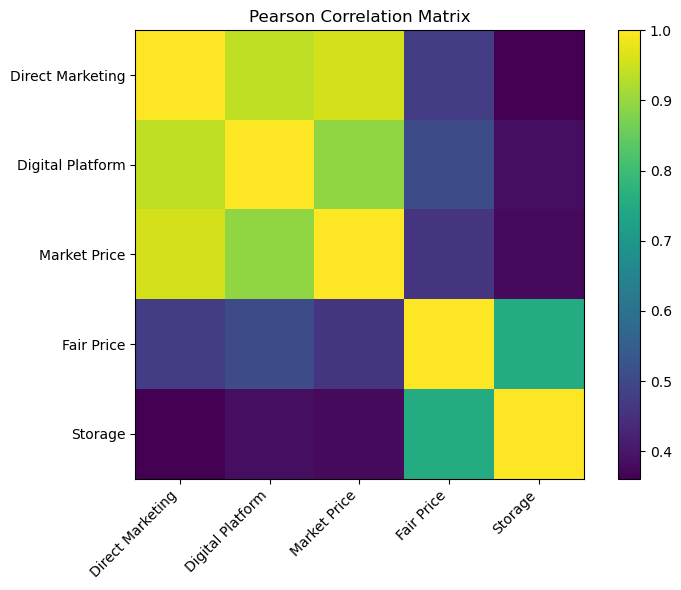

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(corr_matrix, interpolation='nearest')

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Pearson Correlation Matrix")

plt.tight_layout()

plt.show()

**5.4 BINARY LOGISTIC REGRESSION**

****5.4.1 VIF****

In [20]:
# ==========================================================
# VARIANCE INFLATION FACTOR (VIF)
# ==========================================================

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

print("="*80)
print("VARIANCE INFLATION FACTOR (VIF)")
print("="*80)

# ----------------------------------------------------------
# Independent Variables
# ----------------------------------------------------------

X = df[[

'Are you aware of direct marketing methods for agricultural products?_code',

'Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?_code',

'Do you receive proper information about market prices?_code',

'Are storage facilities adequate for preserving agricultural products?_code'

]]

X.columns = [

'Direct_Marketing',

'Digital_Platform',

'Market_Price_Info',

'Storage_Facilities'

]

# Add Constant
X = sm.add_constant(X)

# Calculate VIF
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [

variance_inflation_factor(X.values, i)

for i in range(X.shape[1])

]

print("\n")
print(vif)

VARIANCE INFLATION FACTOR (VIF)


             Variable        VIF
0               const   3.709677
1    Direct_Marketing  20.062112
2    Digital_Platform   8.471340
3   Market_Price_Info  12.245430
4  Storage_Facilities   1.191659


***5.4.2 BINARY LOGISTIC REGRESSION***

In [21]:
# ==========================================================
# BINARY LOGISTIC REGRESSION
# ==========================================================

import pandas as pd
import statsmodels.api as sm

print("="*80)
print("BINARY LOGISTIC REGRESSION")
print("="*80)

print("\nObjective:")
print("To examine whether market price information significantly influences the likelihood of receiving a fair price for agricultural products.")

# ----------------------------------------------------------
# Dependent Variable (Y)
# ----------------------------------------------------------

y = df['Do you feel you get a fair price for your products?_code']

# ----------------------------------------------------------
# Independent Variable (X)
# ----------------------------------------------------------

X = df[['Do you receive proper information about market prices?_code']]

X.columns = ['Market_Price_Information']

# ----------------------------------------------------------
# Add Constant
# ----------------------------------------------------------

X = sm.add_constant(X)

# ----------------------------------------------------------
# Logistic Regression
# ----------------------------------------------------------

model = sm.Logit(y, X)

result = model.fit()

print("\n")
print(result.summary())

BINARY LOGISTIC REGRESSION

Objective:
To examine whether market price information significantly influences the likelihood of receiving a fair price for agricultural products.
Optimization terminated successfully.
         Current function value: 0.532362
         Iterations 7


                                              Logit Regression Results                                              
Dep. Variable:     Do you feel you get a fair price for your products?_code   No. Observations:                  115
Model:                                                                Logit   Df Residuals:                      113
Method:                                                                 MLE   Df Model:                            1
Date:                                                      Fri, 10 Jul 2026   Pseudo R-squ.:                  0.1998
Time:                                                              06:30:32   Log-Likelihood:                -61.222
converged:        

**5.5 DECISION TREE CLASSIFICATION**

In [22]:
# ==========================================================
# DECISION TREE CLASSIFICATION
# ==========================================================

import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("="*80)
print("DECISION TREE CLASSIFICATION")
print("="*80)

print("\nObjective:")
print("To develop a predictive model for identifying whether rural farmers receive a fair price for their agricultural products.")

# ----------------------------------------------------------
# Independent Variables
# ----------------------------------------------------------

X = df[[

'Are you aware of direct marketing methods for agricultural products?_code',

'Are you using digital platforms (WhatsApp UPI Facebook etc.) for selling?_code',

'Do you receive proper information about market prices?_code',

'Are storage facilities adequate for preserving agricultural products?_code'

]]

X.columns = [

'Direct_Marketing',

'Digital_Platform',

'Market_Price_Info',

'Storage_Facilities'

]

# ----------------------------------------------------------
# Target Variable
# ----------------------------------------------------------

y = df['Do you feel you get a fair price for your products?_code']

# ----------------------------------------------------------
# Train Test Split
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

X,
y,

test_size=0.20,

random_state=42

)

# ----------------------------------------------------------
# Decision Tree Model
# ----------------------------------------------------------

model = DecisionTreeClassifier(

criterion='entropy',

max_depth=3,

random_state=42

)

model.fit(X_train, y_train)

# ----------------------------------------------------------
# Prediction
# ----------------------------------------------------------

y_pred = model.predict(X_test)

# ----------------------------------------------------------
# Accuracy
# ----------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n")
print("="*80)
print("MODEL PERFORMANCE")
print("="*80)

print(f"Accuracy : {accuracy:.3f}")

print("\n")

print("="*80)
print("CONFUSION MATRIX")
print("="*80)

print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual: No Fair Price", "Actual: Fair Price"],
    columns=["Predicted: No Fair Price", "Predicted: Fair Price"]
)

print(cm_df)

print("\n")

print("="*80)
print("CLASSIFICATION REPORT")
print("="*80)

print(classification_report(y_test, y_pred))

DECISION TREE CLASSIFICATION

Objective:
To develop a predictive model for identifying whether rural farmers receive a fair price for their agricultural products.


MODEL PERFORMANCE
Accuracy : 0.913


CONFUSION MATRIX
[[18  1]
 [ 1  3]]
                       Predicted: No Fair Price  Predicted: Fair Price
Actual: No Fair Price                        18                      1
Actual: Fair Price                            1                      3


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.75      0.75      0.75         4

    accuracy                           0.91        23
   macro avg       0.85      0.85      0.85        23
weighted avg       0.91      0.91      0.91        23



In [23]:
print(f"Training Accuracy : {model.score(X_train, y_train):.3f}")
print(f"Testing Accuracy  : {model.score(X_test, y_test):.3f}")

Training Accuracy : 0.870
Testing Accuracy  : 0.913


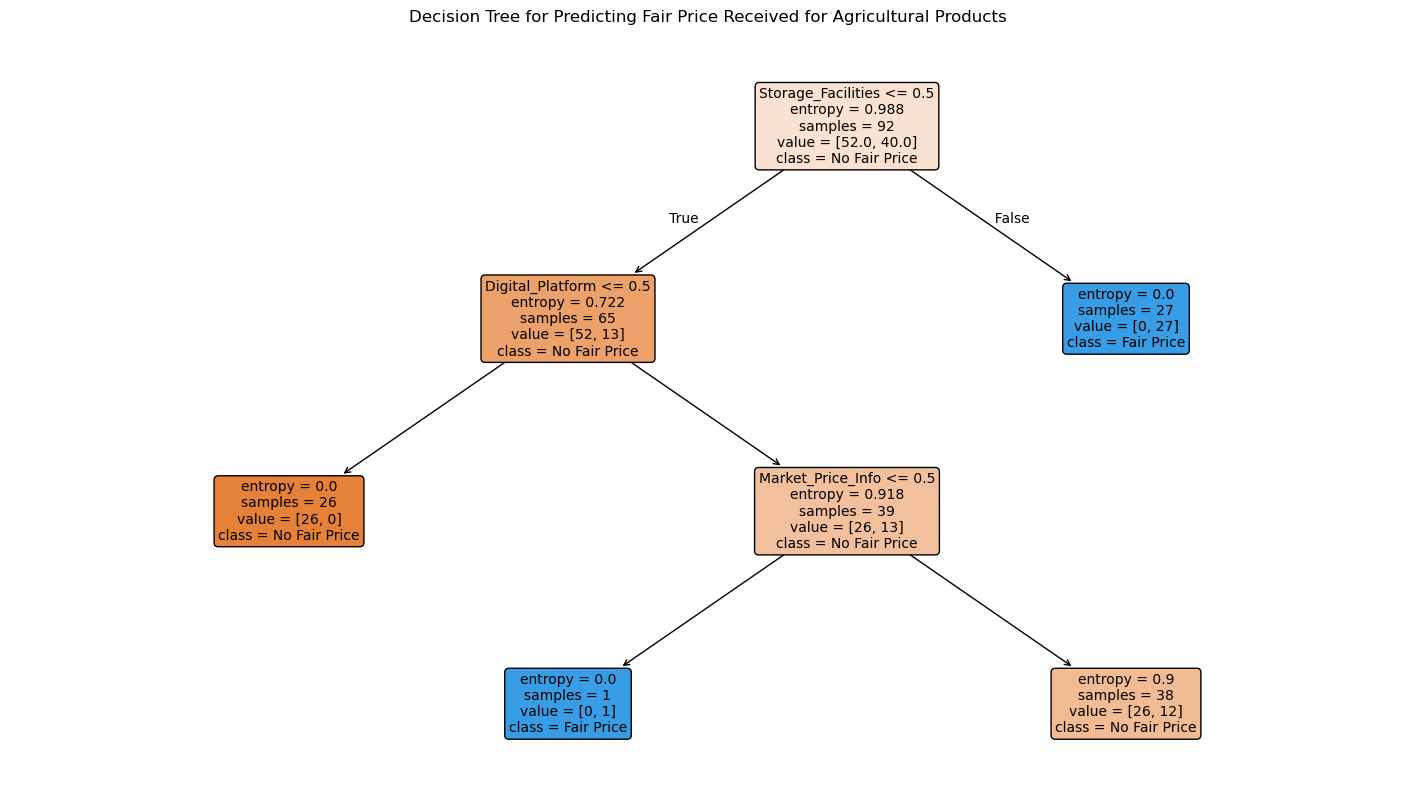

In [24]:
# ==========================================================
# DECISION TREE VISUALIZATION
# ==========================================================

import matplotlib.pyplot as plt

from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No Fair Price', 'Fair Price'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Predicting Fair Price Received for Agricultural Products")

plt.show()

              Feature  Importance
3  Storage_Facilities    0.775306
1    Digital_Platform    0.196053
2   Market_Price_Info    0.028641
0    Direct_Marketing    0.000000


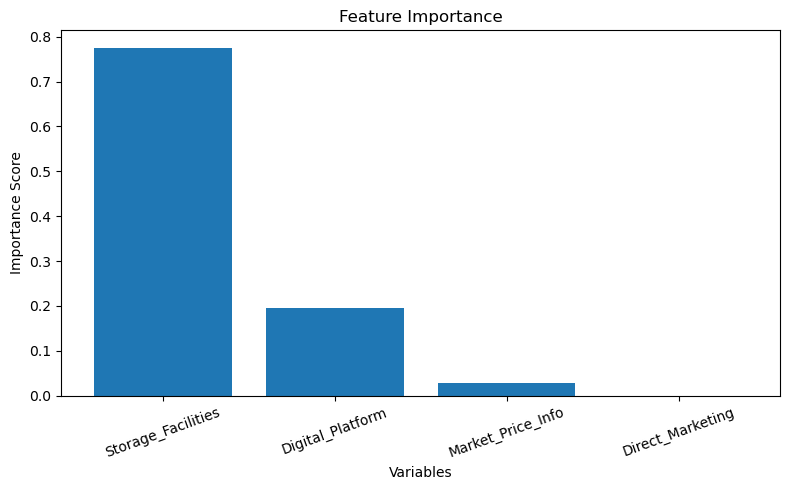

In [25]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({

'Feature': X.columns,

'Importance': model.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")

plt.xlabel("Variables")

plt.ylabel("Importance Score")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Random Forest Regression

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
# RANDOM FOREST CLASSIFICATION


from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    max_depth=3,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

train_accuracy_rf = rf_model.score(X_train, y_train)
test_accuracy_rf = rf_model.score(X_test, y_test)

print("RANDOM FOREST MODEL PERFORMANCE")
print("--------------------------------")
print(f"Training Accuracy : {train_accuracy_rf*100:.2f}%")
print(f"Testing Accuracy  : {test_accuracy_rf*100:.2f}%")
print(f"Overall Accuracy  : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")

RANDOM FOREST MODEL PERFORMANCE
--------------------------------
Training Accuracy : 86.96%
Testing Accuracy  : 91.30%
Overall Accuracy  : 91.30%


### Confusion Matrix.

In [29]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("CONFUSION MATRIX")
print(cm_rf)

CONFUSION MATRIX
[[18  1]
 [ 1  3]]


### Classification Report

In [30]:
from sklearn.metrics import classification_report

print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_rf,
                            target_names=["No Fair Price","Fair Price"]))

CLASSIFICATION REPORT
               precision    recall  f1-score   support

No Fair Price       0.95      0.95      0.95        19
   Fair Price       0.75      0.75      0.75         4

     accuracy                           0.91        23
    macro avg       0.85      0.85      0.85        23
 weighted avg       0.91      0.91      0.91        23



### Feature Importance

             Variable  Importance Score  Rank
0  Storage_Facilities          0.610921     1
1    Digital_Platform          0.236730     2
2    Direct_Marketing          0.094098     3
3   Market_Price_Info          0.058251     4


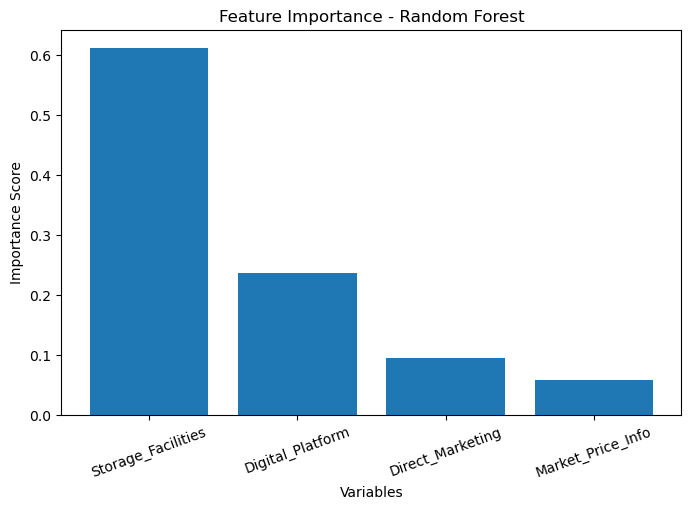

In [31]:
# ==========================
# FEATURE IMPORTANCE
# ==========================

import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance Score': rf_model.feature_importances_
})

# Sort in descending order
feature_importance = feature_importance.sort_values(
    by='Importance Score',
    ascending=False
).reset_index(drop=True)

# Add Rank
feature_importance['Rank'] = feature_importance.index + 1

print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(8,5))
plt.bar(feature_importance['Variable'],
        feature_importance['Importance Score'])
plt.xlabel("Variables")
plt.ylabel("Importance Score")
plt.title("Feature Importance - Random Forest")
plt.xticks(rotation=20)
plt.show()

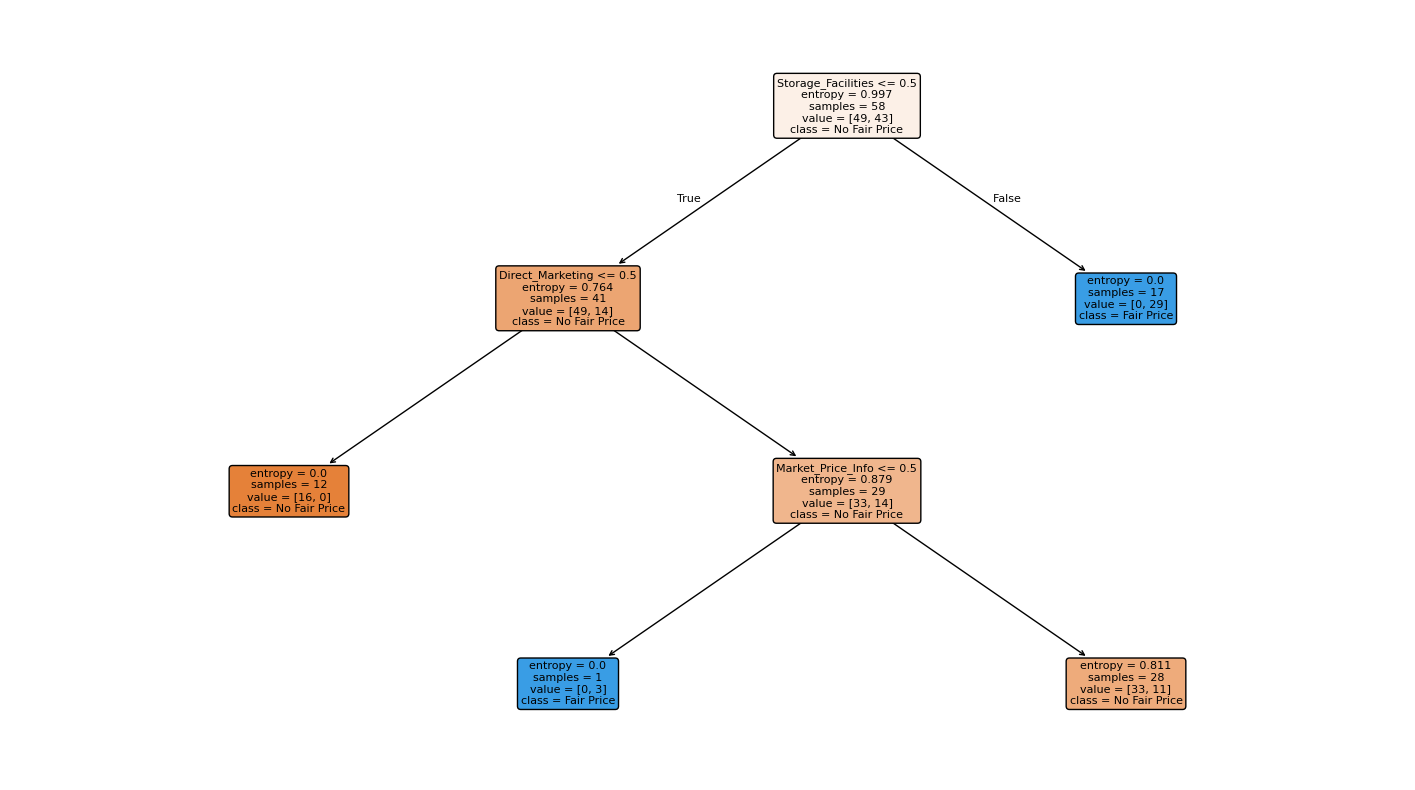

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plot_tree(
    rf_model.estimators_[0],   # first tree
    feature_names=X.columns,
    class_names=['No Fair Price','Fair Price'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

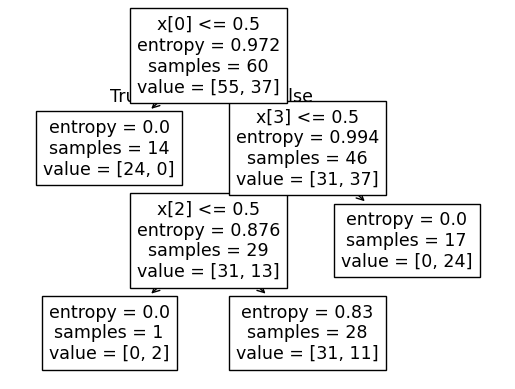

In [33]:
for tree in rf_model.estimators_:
    plot_tree(tree)